In [12]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

class celebADataset(Dataset):
    def __init__(self, root_dir, transform = None):
        '''
        Args:
            root_dir (string): Directort with all the images.
            transform (callable, optional): Optional transform to be applied on a sample.
        '''
        self.root_dir = root_dir
        self.transform = transform
    
        #Get all image file paaths from directory
        self.image_paths = [os.path.join(root_dir, img) for img in os.listdir(root_dir) if img.endswith('.jpg')]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        #Load image
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        #Apply the transform if provided
        if self.transform:
            image = self.transform(image)

        return image
        

In [13]:
# Define transformations (resize, crop, convert to tensor, normalize)
transform = transforms. Compose([
    transforms.Resize(64), # Resize images to 64x64
    transforms.CenterCrop(64), # Crop center to 64x64
    transforms.ToTensor(), # Convert images to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normalize to [-1, 1]

])

# Load celebA dataset from the specified directory
dataset_path = 'D:\GAN\demo\img_align_celeba\img_align_celeba'
dataset = celebADataset(root_dir=dataset_path, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

# Check how many images are Loaded
print(f"Total number of images loaded: {len(dataset)}")

<>:11: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:11: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
C:\Users\halda\AppData\Local\Temp\ipykernel_21496\463942144.py:11: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
  dataset_path = 'D:\GAN\demo\img_align_celeba\img_align_celeba'


Total number of images loaded: 202599


In [14]:
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision
import numpy as np

# Generator and Discriminator classes (same as previously described)
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super(Generator, self) .__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn. ReLU(True),
            nn.Linear(1024, img_channels * 64 * 64),
            nn. Tanh()
        )
    
    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) # Reshape to image format
        return img

In [15]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self) .__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, img):
        return self.model(img)

In [16]:
import torch.optim as optim
# Loss function and optimizers
adversarial_loss = nn.BCELoss()

generator = Generator(z_dim=100)

discriminator = Discriminator()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

generator = generator.to(device)
discriminator = discriminator.to(device)

[Epoch 0/10] [Batch 0/1583] [D loss: 0.6916037201881409] [G loss: 0.6821087598800659]
[Epoch 0/10] [Batch 50/1583] [D loss: 0.26588040590286255] [G loss: 1.1068122386932373]
[Epoch 0/10] [Batch 100/1583] [D loss: 0.16530723869800568] [G loss: 1.8003214597702026]
[Epoch 0/10] [Batch 150/1583] [D loss: 0.30843549966812134] [G loss: 1.1956443786621094]
[Epoch 0/10] [Batch 200/1583] [D loss: 0.17806246876716614] [G loss: 2.619248867034912]
[Epoch 0/10] [Batch 250/1583] [D loss: 0.07618176937103271] [G loss: 2.980531692504883]
[Epoch 0/10] [Batch 300/1583] [D loss: 0.03271709382534027] [G loss: 4.874040603637695]
[Epoch 0/10] [Batch 350/1583] [D loss: 0.010371256619691849] [G loss: 7.133853912353516]
[Epoch 0/10] [Batch 400/1583] [D loss: 0.015499824658036232] [G loss: 5.025982856750488]
[Epoch 0/10] [Batch 450/1583] [D loss: 0.49877431988716125] [G loss: 7.175262451171875]
[Epoch 0/10] [Batch 500/1583] [D loss: 0.08505561202764511] [G loss: 4.013250350952148]
[Epoch 0/10] [Batch 550/1583] 

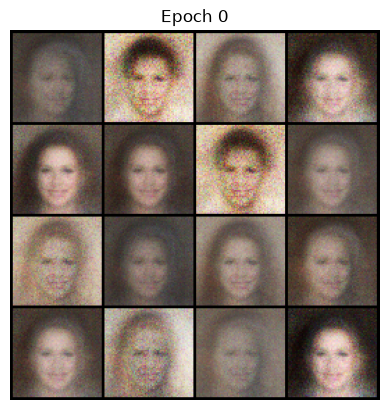

[Epoch 1/10] [Batch 0/1583] [D loss: 0.2906859517097473] [G loss: 4.238970756530762]
[Epoch 1/10] [Batch 50/1583] [D loss: 0.21659699082374573] [G loss: 3.837869167327881]
[Epoch 1/10] [Batch 100/1583] [D loss: 0.37629956007003784] [G loss: 3.3200488090515137]
[Epoch 1/10] [Batch 150/1583] [D loss: 0.17582616209983826] [G loss: 3.058919906616211]
[Epoch 1/10] [Batch 200/1583] [D loss: 0.3059503734111786] [G loss: 2.8209848403930664]
[Epoch 1/10] [Batch 250/1583] [D loss: 0.28204742074012756] [G loss: 3.770298480987549]
[Epoch 1/10] [Batch 300/1583] [D loss: 0.2435559332370758] [G loss: 4.307501792907715]
[Epoch 1/10] [Batch 350/1583] [D loss: 0.3344000577926636] [G loss: 3.0630593299865723]
[Epoch 1/10] [Batch 400/1583] [D loss: 0.19300219416618347] [G loss: 2.928097724914551]
[Epoch 1/10] [Batch 450/1583] [D loss: 0.29159581661224365] [G loss: 2.7748615741729736]
[Epoch 1/10] [Batch 500/1583] [D loss: 0.21787461638450623] [G loss: 2.942355155944824]
[Epoch 1/10] [Batch 550/1583] [D lo

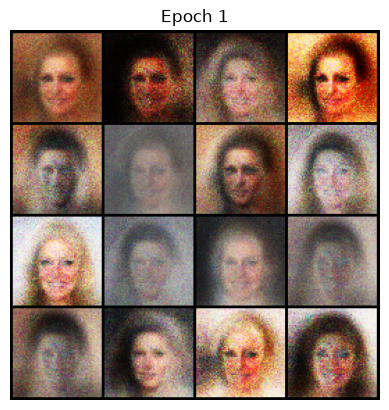

[Epoch 2/10] [Batch 0/1583] [D loss: 0.35628432035446167] [G loss: 2.0258402824401855]
[Epoch 2/10] [Batch 50/1583] [D loss: 0.3632952570915222] [G loss: 2.1697263717651367]
[Epoch 2/10] [Batch 100/1583] [D loss: 0.32686716318130493] [G loss: 2.9070897102355957]
[Epoch 2/10] [Batch 150/1583] [D loss: 0.22534668445587158] [G loss: 2.721143960952759]
[Epoch 2/10] [Batch 200/1583] [D loss: 0.4161422550678253] [G loss: 1.909075140953064]
[Epoch 2/10] [Batch 250/1583] [D loss: 0.3384450078010559] [G loss: 3.4431724548339844]
[Epoch 2/10] [Batch 300/1583] [D loss: 0.25844907760620117] [G loss: 2.3510398864746094]
[Epoch 2/10] [Batch 350/1583] [D loss: 0.4263562262058258] [G loss: 2.47727632522583]
[Epoch 2/10] [Batch 400/1583] [D loss: 0.3010907769203186] [G loss: 2.738511085510254]
[Epoch 2/10] [Batch 450/1583] [D loss: 0.39050668478012085] [G loss: 3.6611218452453613]
[Epoch 2/10] [Batch 500/1583] [D loss: 0.3768100142478943] [G loss: 2.3717916011810303]
[Epoch 2/10] [Batch 550/1583] [D lo

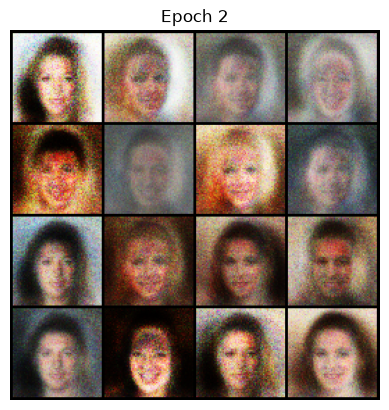

[Epoch 3/10] [Batch 0/1583] [D loss: 0.3919030427932739] [G loss: 2.5366053581237793]
[Epoch 3/10] [Batch 50/1583] [D loss: 0.3561333417892456] [G loss: 2.1996331214904785]
[Epoch 3/10] [Batch 100/1583] [D loss: 0.42007261514663696] [G loss: 1.633446216583252]
[Epoch 3/10] [Batch 150/1583] [D loss: 0.41242027282714844] [G loss: 1.8744487762451172]
[Epoch 3/10] [Batch 200/1583] [D loss: 0.5640015602111816] [G loss: 2.2564780712127686]
[Epoch 3/10] [Batch 250/1583] [D loss: 0.4519103765487671] [G loss: 2.2354648113250732]
[Epoch 3/10] [Batch 300/1583] [D loss: 0.4990087151527405] [G loss: 2.012986183166504]
[Epoch 3/10] [Batch 350/1583] [D loss: 0.44924741983413696] [G loss: 2.2359070777893066]
[Epoch 3/10] [Batch 400/1583] [D loss: 0.5083237290382385] [G loss: 2.0148966312408447]
[Epoch 3/10] [Batch 450/1583] [D loss: 0.4695931375026703] [G loss: 2.098921775817871]
[Epoch 3/10] [Batch 500/1583] [D loss: 0.4626445174217224] [G loss: 1.8441323041915894]
[Epoch 3/10] [Batch 550/1583] [D lo

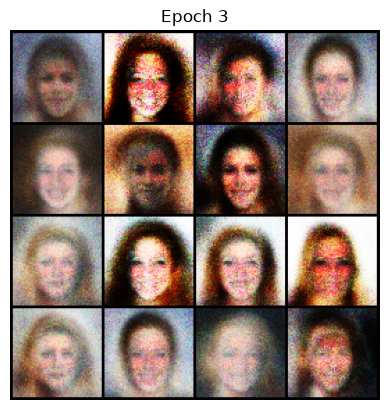

[Epoch 4/10] [Batch 0/1583] [D loss: 0.4951627254486084] [G loss: 1.7849345207214355]
[Epoch 4/10] [Batch 50/1583] [D loss: 0.3671838939189911] [G loss: 2.4337916374206543]
[Epoch 4/10] [Batch 100/1583] [D loss: 0.419952392578125] [G loss: 2.2062253952026367]
[Epoch 4/10] [Batch 150/1583] [D loss: 0.3681950569152832] [G loss: 1.996924638748169]
[Epoch 4/10] [Batch 200/1583] [D loss: 0.45150941610336304] [G loss: 1.5398266315460205]
[Epoch 4/10] [Batch 250/1583] [D loss: 0.4633414149284363] [G loss: 1.905977487564087]
[Epoch 4/10] [Batch 300/1583] [D loss: 0.44632387161254883] [G loss: 1.8357014656066895]
[Epoch 4/10] [Batch 350/1583] [D loss: 0.4269751310348511] [G loss: 2.084791660308838]
[Epoch 4/10] [Batch 400/1583] [D loss: 0.43755781650543213] [G loss: 1.8364287614822388]
[Epoch 4/10] [Batch 450/1583] [D loss: 0.42146003246307373] [G loss: 1.7151281833648682]
[Epoch 4/10] [Batch 500/1583] [D loss: 0.4815444350242615] [G loss: 1.8503302335739136]
[Epoch 4/10] [Batch 550/1583] [D lo

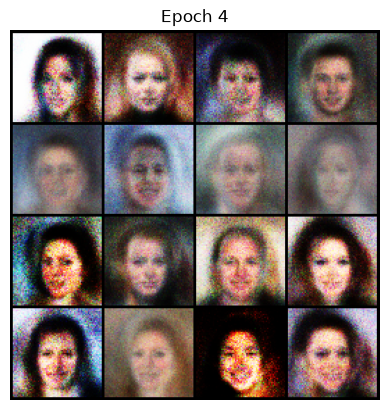

[Epoch 5/10] [Batch 0/1583] [D loss: 0.4620898365974426] [G loss: 1.7752203941345215]
[Epoch 5/10] [Batch 50/1583] [D loss: 0.47997426986694336] [G loss: 1.5848389863967896]
[Epoch 5/10] [Batch 100/1583] [D loss: 0.5279642939567566] [G loss: 2.12320613861084]
[Epoch 5/10] [Batch 150/1583] [D loss: 0.5134333968162537] [G loss: 1.3292587995529175]
[Epoch 5/10] [Batch 200/1583] [D loss: 0.5557582378387451] [G loss: 1.8129699230194092]
[Epoch 5/10] [Batch 250/1583] [D loss: 0.5391228199005127] [G loss: 1.6076879501342773]
[Epoch 5/10] [Batch 300/1583] [D loss: 0.45861849188804626] [G loss: 2.1621382236480713]
[Epoch 5/10] [Batch 350/1583] [D loss: 0.520298182964325] [G loss: 1.4086180925369263]
[Epoch 5/10] [Batch 400/1583] [D loss: 0.4813690483570099] [G loss: 2.0504398345947266]
[Epoch 5/10] [Batch 450/1583] [D loss: 0.5115745067596436] [G loss: 1.7636027336120605]
[Epoch 5/10] [Batch 500/1583] [D loss: 0.4843713045120239] [G loss: 1.6828501224517822]
[Epoch 5/10] [Batch 550/1583] [D los

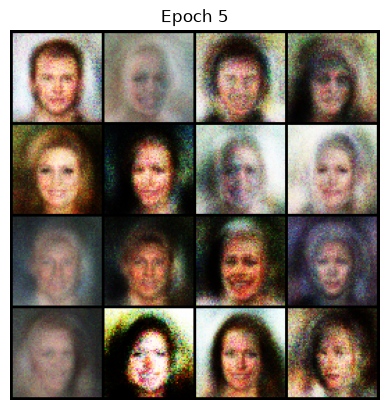

[Epoch 6/10] [Batch 0/1583] [D loss: 0.5798845291137695] [G loss: 1.1841018199920654]
[Epoch 6/10] [Batch 50/1583] [D loss: 0.5818676948547363] [G loss: 1.33768892288208]
[Epoch 6/10] [Batch 100/1583] [D loss: 0.5905667543411255] [G loss: 1.411015272140503]
[Epoch 6/10] [Batch 150/1583] [D loss: 0.5814000964164734] [G loss: 1.1428838968276978]
[Epoch 6/10] [Batch 200/1583] [D loss: 0.5317831635475159] [G loss: 1.6307151317596436]
[Epoch 6/10] [Batch 250/1583] [D loss: 0.5356220006942749] [G loss: 1.4351465702056885]
[Epoch 6/10] [Batch 300/1583] [D loss: 0.5147813558578491] [G loss: 1.5592451095581055]
[Epoch 6/10] [Batch 350/1583] [D loss: 0.5325459241867065] [G loss: 1.7446672916412354]
[Epoch 6/10] [Batch 400/1583] [D loss: 0.5521037578582764] [G loss: 1.4308022260665894]
[Epoch 6/10] [Batch 450/1583] [D loss: 0.5584182739257812] [G loss: 1.4039416313171387]
[Epoch 6/10] [Batch 500/1583] [D loss: 0.5273398160934448] [G loss: 1.637071132659912]
[Epoch 6/10] [Batch 550/1583] [D loss: 

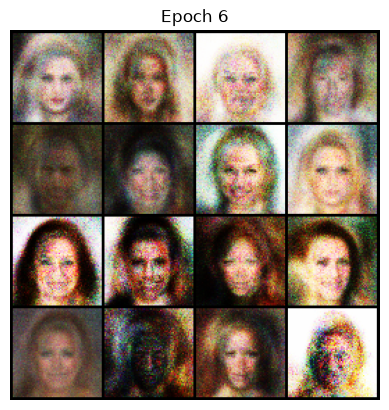

[Epoch 7/10] [Batch 0/1583] [D loss: 0.5049718618392944] [G loss: 1.2030763626098633]
[Epoch 7/10] [Batch 50/1583] [D loss: 0.5296487808227539] [G loss: 1.3274836540222168]
[Epoch 7/10] [Batch 100/1583] [D loss: 0.6000958681106567] [G loss: 1.2546947002410889]
[Epoch 7/10] [Batch 150/1583] [D loss: 0.5122305750846863] [G loss: 1.3546698093414307]
[Epoch 7/10] [Batch 200/1583] [D loss: 0.5257595777511597] [G loss: 1.2178469896316528]
[Epoch 7/10] [Batch 250/1583] [D loss: 0.5718188881874084] [G loss: 1.3721165657043457]
[Epoch 7/10] [Batch 300/1583] [D loss: 0.570995032787323] [G loss: 1.3545652627944946]
[Epoch 7/10] [Batch 350/1583] [D loss: 0.5394361615180969] [G loss: 1.1858043670654297]
[Epoch 7/10] [Batch 400/1583] [D loss: 0.5909947752952576] [G loss: 1.4522299766540527]
[Epoch 7/10] [Batch 450/1583] [D loss: 0.5997552871704102] [G loss: 1.308574914932251]
[Epoch 7/10] [Batch 500/1583] [D loss: 0.6059050559997559] [G loss: 1.6666940450668335]
[Epoch 7/10] [Batch 550/1583] [D loss

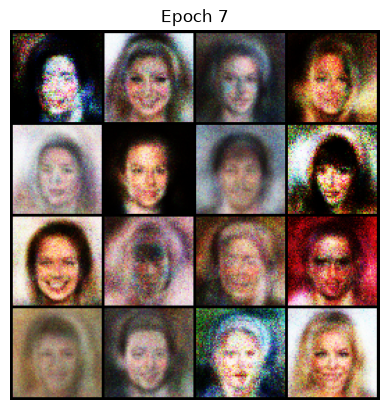

[Epoch 8/10] [Batch 0/1583] [D loss: 0.5640697479248047] [G loss: 1.21299147605896]
[Epoch 8/10] [Batch 50/1583] [D loss: 0.6039830446243286] [G loss: 1.15019690990448]
[Epoch 8/10] [Batch 100/1583] [D loss: 0.5713026523590088] [G loss: 1.1054936647415161]
[Epoch 8/10] [Batch 150/1583] [D loss: 0.5272864103317261] [G loss: 1.6071341037750244]
[Epoch 8/10] [Batch 200/1583] [D loss: 0.5739941596984863] [G loss: 1.3690874576568604]
[Epoch 8/10] [Batch 250/1583] [D loss: 0.5228297710418701] [G loss: 1.2218410968780518]
[Epoch 8/10] [Batch 300/1583] [D loss: 0.5808541178703308] [G loss: 1.1772332191467285]
[Epoch 8/10] [Batch 350/1583] [D loss: 0.5633751153945923] [G loss: 1.2650389671325684]
[Epoch 8/10] [Batch 400/1583] [D loss: 0.5436553955078125] [G loss: 1.2230112552642822]
[Epoch 8/10] [Batch 450/1583] [D loss: 0.5125507116317749] [G loss: 1.152540922164917]
[Epoch 8/10] [Batch 500/1583] [D loss: 0.5876787900924683] [G loss: 1.2131978273391724]
[Epoch 8/10] [Batch 550/1583] [D loss: 0

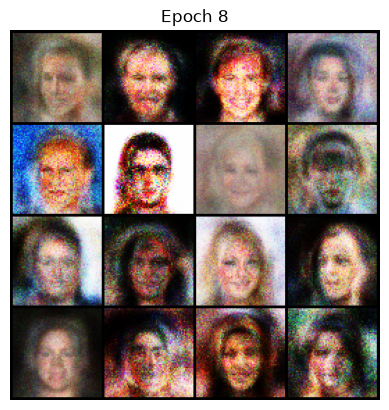

[Epoch 9/10] [Batch 0/1583] [D loss: 0.5621541142463684] [G loss: 1.2276802062988281]
[Epoch 9/10] [Batch 50/1583] [D loss: 0.634368360042572] [G loss: 1.2395825386047363]
[Epoch 9/10] [Batch 100/1583] [D loss: 0.5813689231872559] [G loss: 1.2126692533493042]
[Epoch 9/10] [Batch 150/1583] [D loss: 0.548438310623169] [G loss: 1.3530123233795166]
[Epoch 9/10] [Batch 200/1583] [D loss: 0.5186671614646912] [G loss: 1.2055026292800903]
[Epoch 9/10] [Batch 250/1583] [D loss: 0.6068694591522217] [G loss: 1.3197481632232666]
[Epoch 9/10] [Batch 300/1583] [D loss: 0.49796199798583984] [G loss: 1.2493650913238525]
[Epoch 9/10] [Batch 350/1583] [D loss: 0.5579098463058472] [G loss: 1.2533336877822876]
[Epoch 9/10] [Batch 400/1583] [D loss: 0.5682700276374817] [G loss: 1.0061182975769043]
[Epoch 9/10] [Batch 450/1583] [D loss: 0.5974094867706299] [G loss: 1.3756494522094727]
[Epoch 9/10] [Batch 500/1583] [D loss: 0.630213737487793] [G loss: 1.0042877197265625]
[Epoch 9/10] [Batch 550/1583] [D loss

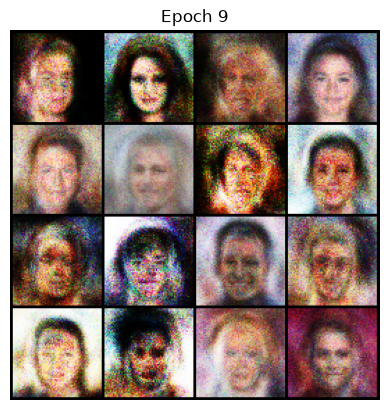

In [17]:
# Training loop
def train(generator, discriminator, dataloader, epochs=5):
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device)).detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device))), valid)
            g_loss.backward()
            optimizer_G.step()

            if i % 50 == 0:
                print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        # Optionally, save generated images at each epoch
        save_generated_images(generator, epoch, device)

def save_generated_images(generator, epoch, device, num_images=16):
    z = torch.randn(num_images, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"Epoch {epoch}")
    plt.axis('off')
    plt.show()

# Start training
train(generator, discriminator, dataloader, epochs=10)